<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
A = 0.1
sigma = 0.2
x0 = np.pi
phi = A * np.exp(-((x - x0)**2) / (2 * sigma**2))
history = [phi.copy()]


In [2]:
dt = 0.02
gamma = 0.005
lam = 0.5
reinforce = 0.02  # strength of echo injection

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    return phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3)

original = phi.copy()

for t in range(300):
    phi = evolve(phi)
    if t == 150:
        echo = reinforce * original
        phi += echo
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

def revival_amplitude(phi):
    return np.max(np.abs(phi))

fidelity = [correlation(h, history[0]) for h in history]
revival = [revival_amplitude(h) for h in history]


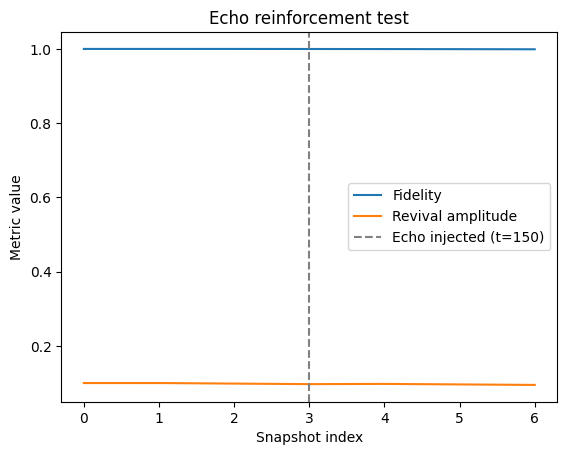

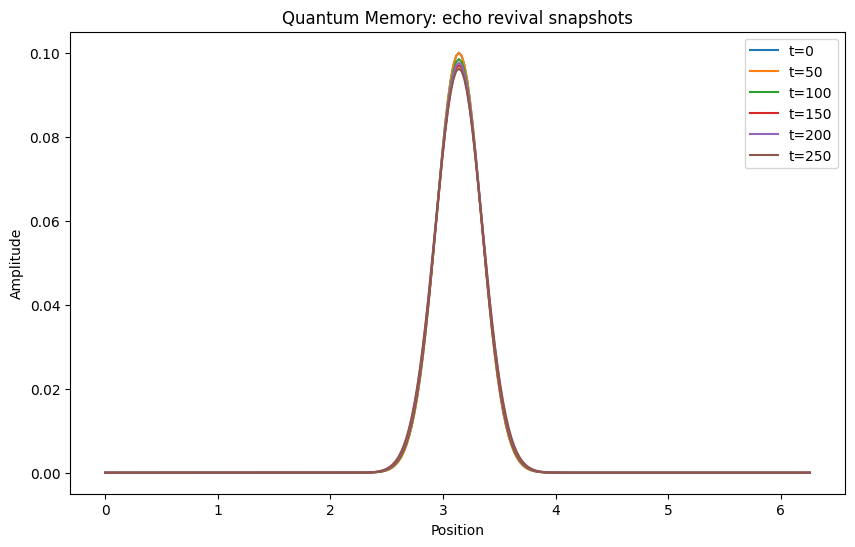

In [4]:
plt.plot(fidelity, label="Fidelity")
plt.plot(revival, label="Revival amplitude")
plt.axvline(x=3, color='gray', linestyle='--', label="Echo injected (t=150)")
plt.xlabel("Snapshot index")
plt.ylabel("Metric value")
plt.title("Echo reinforcement test")
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Quantum Memory: echo revival snapshots")
plt.legend()
plt.show()
